# Notebook 17. Spatial EOF Analysis of Cleaned Event Fields

This notebook performs the **true spatial EOF analysis** requested after the cleaned low-level clustering decision.

Why this notebook exists:

- the `Notebook 08/09/15` PCA work is on a small event-level feature table, so it does **not** produce spatial EOF maps
- `Notebook 16` shows what the cleaned primary clusters look like physically, but it still does not tell us where the dominant event-to-event variance is realized spatially
- this notebook therefore builds gridded event stacks, computes the first three EOF/PC modes for several key fields, and plots those spatial patterns directly

What this notebook does:

- loads the cleaned event labels from `Notebook 15`
- uses the cleaned `k = 2` labels as the primary cluster context for plotting and score summaries
- rebuilds or restores gridded event stacks for selected low-level and upper-level fields
- applies the Russian-coastal exclusion to the low-level fields before EOF analysis, matching the cleaned clustering framework
- computes EOF1, EOF2, and EOF3 for each selected field using latitude weighting
- saves EOF regression-pattern maps, explained variance tables, and PC score tables
- plots EOF1–EOF3 maps plus PC-score scatter colored by the cleaned `k = 2` labels

What this notebook does **not** do:

- it does not rerun the clustering decision logic from `Notebook 15`
- it does not rebuild the cleaned composite figures from `Notebook 16`
- it does not do the Cluster-1 moisture-flux quartile analysis or the date-pairing analysis yet


In [6]:

import os
import shutil
import subprocess
import sys

REPO_URL = "https://github.com/angelicasophyaramirez-blip/JPCZcatalogcolab.git"
BRANCH = "main"
REPO_DIR = "/content/JPCZcatalog"
FORCE_REFRESH_REPO = False
PERSIST_OUTPUTS_TO_DRIVE = True
DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/JPCZcatalog_outputs"

if PERSIST_OUTPUTS_TO_DRIVE:
    from google.colab import drive

    drive.mount("/content/drive")
    os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)
    print("Persistent output dir:", DRIVE_OUTPUT_DIR)

os.chdir("/content")

if FORCE_REFRESH_REPO and os.path.exists(REPO_DIR):
    shutil.rmtree(REPO_DIR)
    print("Removed existing repo clone:", REPO_DIR)

if not os.path.exists(REPO_DIR):
    proc = subprocess.run(
        ["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, REPO_DIR],
        text=True,
        capture_output=True,
    )
    print(proc.stdout)
    print(proc.stderr)
    if proc.returncode != 0:
        raise RuntimeError(f"git clone failed:\n{proc.stderr}")

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", f"{REPO_DIR}/requirements-colab.txt"],
        check=True,
    )
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-e", REPO_DIR],
        check=True,
    )
else:
    print("Using existing repo clone:", REPO_DIR)

os.chdir(REPO_DIR)
src_dir = os.path.join(REPO_DIR, "src")
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

print("Working directory:", os.getcwd())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Persistent output dir: /content/drive/MyDrive/JPCZcatalog_outputs
Using existing repo clone: /content/JPCZcatalog
Working directory: /content/JPCZcatalog


In [7]:

from pathlib import Path
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from jpcz_catalog.analysis import add_japan_local_time_columns
from jpcz_catalog.config import (
    JPCZ_POLYGON_VERTICES,
    OBJECTIVE_SUBTYPE_DOMAIN,
    WORKING_DOMAIN,
    BoundingBox,
)
from jpcz_catalog.detect import compute_divergence_field, prepare_detection_geometry
from jpcz_catalog.diagnostics import (
    compute_ageostrophic_divergence_field,
    compute_geopotential_height_field,
    load_offset_snapshot,
    load_snapshot,
)
from jpcz_catalog.era5 import open_arco_era5
from jpcz_catalog.subtypes import compute_monthly_geopotential_height_climatology

CLEANED_RUN_EXPORT_DIR = Path("outputs/verification/objective_subtype_low_level_cleaned_sensitivity")
EOF_EXPORT_DIR = Path("outputs/verification/objective_subtype_eof_analysis")
EOF_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR = Path("outputs/verification/objective_subtype_eof_plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

CLEANED_CLUSTERED_EVENTS_PATH = CLEANED_RUN_EXPORT_DIR / "clustered_events_cleaned_low_level_k2_k3_k4.csv"
NOTEBOOK15_SOLUTION_SUMMARY_PATH = CLEANED_RUN_EXPORT_DIR / "cleaned_low_level_solution_summary.csv"
NOTEBOOK15_QUALITY_SCAN_LONG_PATH = CLEANED_RUN_EXPORT_DIR / "cleaned_low_level_quality_scan_by_solution.csv"

Z850_CLIMATOLOGY_PATH = Path("outputs/verification/z850_ndjf_monthly_climatology.nc")
Z300_CLIMATOLOGY_PATH = Path("outputs/verification/z300_ndjf_monthly_climatology_working_domain.nc")

LOW_LEVEL_STACK_PATH = EOF_EXPORT_DIR / "cleaned_low_level_eof_event_fields.nc"
LOW_LEVEL_STACK_PARTIAL_PATH = EOF_EXPORT_DIR / "cleaned_low_level_eof_event_fields_partial.nc"
UPPER_LEVEL_STACK_PATH = EOF_EXPORT_DIR / "cleaned_upper_level_eof_event_fields.nc"
UPPER_LEVEL_STACK_PARTIAL_PATH = EOF_EXPORT_DIR / "cleaned_upper_level_eof_event_fields_partial.nc"
FIELD_STACK_STATUS_PATH = EOF_EXPORT_DIR / "cleaned_eof_event_field_status.csv"
FIELD_STACK_SUMMARY_PATH = EOF_EXPORT_DIR / "cleaned_eof_event_field_stack_summary.csv"
EOF_VARIANCE_PATH = EOF_EXPORT_DIR / "cleaned_eof_variance_summary.csv"
EOF_SCORE_PATH = EOF_EXPORT_DIR / "cleaned_eof_pc_scores.csv"
EOF_CLUSTER_SCORE_SUMMARY_PATH = EOF_EXPORT_DIR / "cleaned_eof_cluster_pc_score_summary.csv"
EOF_PATTERN_SUMMARY_PATH = EOF_EXPORT_DIR / "cleaned_eof_pattern_summary.csv"
PLOT_INVENTORY_PATH = EOF_EXPORT_DIR / "cleaned_eof_plot_inventory.csv"

PRIMARY_CLUSTER_COLUMN = "cleaned_cluster_ward_2"
EXPLORATORY_CLUSTER_COLUMN = "cleaned_cluster_ward_3"
PRIMARY_CLUSTER_K = 2
ERA5_TIME_CHUNK = 48
SYNOPTIC_OFFSETS = (-12, 0, 12)
CHECKPOINT_EVERY_EVENTS = 10
SAVE_PLOTS = True
FORCE_REBUILD_EOF_EVENT_FIELDS = False
MIN_EVENT_FRACTION_FOR_VALID_GRIDCELL = 1.0
N_EOF_MODES = 3

LOW_LEVEL_COMPOSITE_DOMAIN = OBJECTIVE_SUBTYPE_DOMAIN
UPPER_LEVEL_COMPOSITE_DOMAIN = WORKING_DOMAIN
LOW_LEVEL_PLOT_DOMAIN = OBJECTIVE_SUBTYPE_DOMAIN
UPPER_LEVEL_PLOT_DOMAIN = WORKING_DOMAIN

RUSSIAN_COASTAL_EXCLUSION_BOXES = (
    BoundingBox(lon_min=130.5, lon_max=135.5, lat_min=42.0, lat_max=45.0),
    BoundingBox(lon_min=133.5, lon_max=139.5, lat_min=44.0, lat_max=47.25),
)

EOF_FIELD_SPECS = [
    {
        "field": "divergence_925_peak",
        "domain_key": "low",
        "plot_domain": LOW_LEVEL_PLOT_DOMAIN,
        "title": "925 hPa signed divergence",
        "field_label": "925 hPa signed divergence (Russian coastal exclusion)",
        "units": "1e-5 s^-1",
        "plot_cmap": "RdBu_r",
    },
    {
        "field": "z850_anomaly_min_tminus12_to_tplus12",
        "domain_key": "low",
        "plot_domain": LOW_LEVEL_PLOT_DOMAIN,
        "title": "850 hPa z anomaly minimum",
        "field_label": "850 hPa z anomaly minimum over t-12/t0/t+12 (Russian coastal exclusion)",
        "units": "gpm",
        "plot_cmap": "RdBu_r",
    },
    {
        "field": "vertical_moisture_flux_proxy_850_peak",
        "domain_key": "low",
        "plot_domain": LOW_LEVEL_PLOT_DOMAIN,
        "title": "850 hPa vertical moisture-flux proxy",
        "field_label": "850 hPa vertical moisture-flux proxy at event peak (Russian coastal exclusion)",
        "units": "1e-3 Pa s^-1",
        "plot_cmap": "RdBu_r",
    },
    {
        "field": "z300_anomaly_peak",
        "domain_key": "upper",
        "plot_domain": UPPER_LEVEL_PLOT_DOMAIN,
        "title": "300 hPa z anomaly",
        "field_label": "300 hPa geopotential-height anomaly at event peak",
        "units": "gpm",
        "plot_cmap": "RdBu_r",
    },
    {
        "field": "ageostrophic_divergence_300_peak",
        "domain_key": "upper",
        "plot_domain": UPPER_LEVEL_PLOT_DOMAIN,
        "title": "300 hPa ageostrophic divergence",
        "field_label": "300 hPa ageostrophic divergence at event peak",
        "units": "1e-5 s^-1",
        "plot_cmap": "RdBu_r",
    },
]
FIELD_SPEC_LOOKUP = {spec["field"]: spec for spec in EOF_FIELD_SPECS}
CLUSTER_COLOR_MAP = {1: "#1f78b4", 2: "#d95f02", 3: "#7570b3", 4: "#66a61e"}


def maybe_copy_to_drive(path: Path, *, verbose: bool = True):
    if not PERSIST_OUTPUTS_TO_DRIVE:
        return None
    drive_path = Path(DRIVE_OUTPUT_DIR) / path.name
    if path.is_file():
        shutil.copy2(path, drive_path)
        if verbose:
            print("Copied to Drive:", drive_path)
        return drive_path
    return None



def restore_from_drive_cache(path: Path) -> bool:
    if not PERSIST_OUTPUTS_TO_DRIVE:
        return False
    drive_path = Path(DRIVE_OUTPUT_DIR) / path.name
    if not drive_path.exists():
        return False
    path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(drive_path, path)
    print("Restored from Drive:", drive_path, "->", path)
    return True



def ordinal_word(value: int) -> str:
    lookup = {1: "first", 2: "second", 3: "third", 4: "fourth", 5: "fifth"}
    return lookup.get(value, f"{value}th")



def size_rank_descriptor(rank: int, total: int) -> str:
    if total <= 1:
        return "only subgroup"
    if rank == 1:
        return "largest subgroup"
    if rank == total:
        return "smallest subgroup"
    return f"{ordinal_word(rank)}-largest subgroup"



def build_cluster_labels_from_counts(cluster_counts: pd.Series | dict[int, int]):
    counts_dict = {int(cluster_id): int(n_events) for cluster_id, n_events in dict(cluster_counts).items()}
    ranked = sorted(counts_dict.items(), key=lambda item: (-item[1], item[0]))
    rank_lookup = {cluster_id: rank for rank, (cluster_id, _) in enumerate(ranked, start=1)}
    total = len(ranked)
    long_labels = {}
    short_labels = {}
    rows = []
    for cluster_id, n_events in sorted(counts_dict.items()):
        descriptor = size_rank_descriptor(rank_lookup[cluster_id], total)
        long_labels[cluster_id] = f"Cluster {cluster_id}: n={n_events} ({descriptor})"
        short_labels[cluster_id] = descriptor
        rows.append(
            {
                "cluster_id": cluster_id,
                "n_events": n_events,
                "size_rank": rank_lookup[cluster_id],
                "size_descriptor": descriptor,
                "cluster_label": long_labels[cluster_id],
            }
        )
    return long_labels, short_labels, pd.DataFrame(rows)



def build_russian_coastal_keep_mask(target_field: xr.DataArray) -> xr.DataArray:
    lat_vals = np.asarray(target_field.latitude.values, dtype=float)
    lon_vals = np.asarray(target_field.longitude.values, dtype=float)
    lon2d, lat2d = np.meshgrid(lon_vals, lat_vals)
    keep_mask = np.ones((len(lat_vals), len(lon_vals)), dtype=bool)
    for box in RUSSIAN_COASTAL_EXCLUSION_BOXES:
        in_box = (
            (lon2d >= box.lon_min)
            & (lon2d <= box.lon_max)
            & (lat2d >= box.lat_min)
            & (lat2d <= box.lat_max)
        )
        keep_mask &= ~in_box
    return xr.DataArray(
        keep_mask,
        coords={"latitude": target_field.latitude, "longitude": target_field.longitude},
        dims=("latitude", "longitude"),
        name="russian_coastal_keep_mask",
    )



def load_cached_dataset(path: Path):
    if not path.exists():
        return None
    with xr.open_dataset(path) as ds:
        return ds.load()



def write_checkpoint_dataset(ds: xr.Dataset, path: Path):
    ds.sortby("event_index").to_netcdf(path)
    maybe_copy_to_drive(path)



def attach_event_metadata(event_ds: xr.Dataset, row: pd.Series) -> xr.Dataset:
    event_index = int(row.name)
    event_peak = np.datetime64(pd.Timestamp(row["event_peak"]).to_datetime64())
    expanded = event_ds.expand_dims(event_index=[event_index])
    expanded = expanded.assign_coords(
        event_peak=("event_index", [event_peak]),
        cleaned_cluster_k2=("event_index", [int(row[PRIMARY_CLUSTER_COLUMN])]),
        cleaned_cluster_k3=("event_index", [int(row[EXPLORATORY_CLUSTER_COLUMN])]),
    )
    return expanded



def safe_concat(existing_ds: xr.Dataset | None, new_ds: xr.Dataset) -> xr.Dataset:
    if existing_ds is None:
        return new_ds
    return xr.concat([existing_ds, new_ds], dim="event_index").sortby("event_index")



def load_or_update_climatology(path: Path, *, level: int, label: str, domain, years, months):
    if path.exists():
        climatology = xr.open_dataarray(path).load()
        cached_months = {int(month_value) for month_value in climatology["month"].values.tolist()}
    else:
        climatology = None
        cached_months = set()
    missing_months = sorted(set(months) - cached_months)
    if missing_months:
        print(f"Cached {label} climatology missing months: {missing_months}")
        print(f"Computing missing {label} climatology months one at a time and checkpointing each completed month to Drive.")
        ds = open_arco_era5(chunks={"time": ERA5_TIME_CHUNK})
        for month in missing_months:
            month_climatology = compute_monthly_geopotential_height_climatology(
                ds,
                years=years,
                months=[month],
                domain=domain,
                level=level,
            )
            if climatology is None:
                climatology = month_climatology
            else:
                climatology = xr.concat([climatology, month_climatology], dim="month").sortby("month")
            climatology.to_netcdf(path)
            maybe_copy_to_drive(path)
            print(f"Checkpointed {label} climatology after month {month:02d}")
        climatology_source = "month-by-month checkpoints"
    else:
        climatology_source = "restored cached climatology"
    if climatology is None:
        raise RuntimeError(f"Unable to load or compute the {label} climatology.")
    return climatology, climatology_source



def compute_event_eof_fields(ds: xr.Dataset, row: pd.Series, *, z850_climatology: xr.DataArray, z300_climatology: xr.DataArray, geometry_low=None, geometry_upper=None):
    def strip_nonspatial_coords(field: xr.DataArray, *, keep_dims=("latitude", "longitude", "offset_hours")) -> xr.DataArray:
        drop_coords = [coord_name for coord_name in field.coords if coord_name not in keep_dims]
        if drop_coords:
            field = field.reset_coords(names=drop_coords, drop=True)
        return field

    peak_time = pd.Timestamp(row["event_peak"])

    peak_snapshot_925 = load_snapshot(
        ds,
        peak_time,
        variables=("u_component_of_wind", "v_component_of_wind"),
        domain=LOW_LEVEL_COMPOSITE_DOMAIN,
        level=925,
    )
    if geometry_low is None:
        geometry_low = prepare_detection_geometry(
            peak_snapshot_925.longitude,
            peak_snapshot_925.latitude,
            JPCZ_POLYGON_VERTICES,
        )
    low_dx = geometry_low.dx
    low_dy = geometry_low.dy

    divergence_field = compute_divergence_field(peak_snapshot_925, dx=low_dx, dy=low_dy)
    divergence_925_peak = strip_nonspatial_coords((divergence_field * 1e5).rename("divergence_925_peak"))
    divergence_925_peak.attrs["units"] = "1e-5 s^-1"
    keep_mask_925 = build_russian_coastal_keep_mask(divergence_925_peak)
    divergence_925_peak = divergence_925_peak.where(keep_mask_925)

    moisture_snapshot_850 = load_snapshot(
        ds,
        peak_time,
        variables=("specific_humidity", "vertical_velocity"),
        domain=LOW_LEVEL_COMPOSITE_DOMAIN,
        level=850,
    )
    keep_mask_850 = build_russian_coastal_keep_mask(
        strip_nonspatial_coords(moisture_snapshot_850["specific_humidity"].rename("specific_humidity_850"))
    )

    vertical_moisture_flux_proxy_850_peak = strip_nonspatial_coords((
        -1000.0
        * moisture_snapshot_850["specific_humidity"]
        * moisture_snapshot_850["vertical_velocity"]
    ).rename("vertical_moisture_flux_proxy_850_peak")).where(keep_mask_850)
    vertical_moisture_flux_proxy_850_peak.attrs["units"] = "1e-3 Pa s^-1"

    z850_anomaly_stack = []
    for offset in SYNOPTIC_OFFSETS:
        synoptic_time = peak_time + pd.Timedelta(hours=offset)
        synoptic_snapshot_850 = load_offset_snapshot(
            ds,
            peak_time,
            offset_hours=offset,
            variables=("geopotential",),
            domain=LOW_LEVEL_COMPOSITE_DOMAIN,
            level=850,
        )
        z850 = compute_geopotential_height_field(synoptic_snapshot_850)
        z850_anomaly = strip_nonspatial_coords((z850 - z850_climatology.sel(month=synoptic_time.month))).where(keep_mask_850).expand_dims(offset_hours=[offset])
        z850_anomaly_stack.append(z850_anomaly)
    z850_anomaly_min_tminus12_to_tplus12 = xr.concat(z850_anomaly_stack, dim="offset_hours").min(dim="offset_hours", skipna=True)
    z850_anomaly_min_tminus12_to_tplus12 = z850_anomaly_min_tminus12_to_tplus12.rename("z850_anomaly_min_tminus12_to_tplus12")
    z850_anomaly_min_tminus12_to_tplus12.attrs["units"] = "gpm"

    upper_snapshot_300 = load_snapshot(
        ds,
        peak_time,
        variables=("u_component_of_wind", "v_component_of_wind", "geopotential"),
        domain=UPPER_LEVEL_COMPOSITE_DOMAIN,
        level=300,
    )
    if geometry_upper is None:
        geometry_upper = prepare_detection_geometry(
            upper_snapshot_300.longitude,
            upper_snapshot_300.latitude,
            JPCZ_POLYGON_VERTICES,
        )
    upper_dx = geometry_upper.dx
    upper_dy = geometry_upper.dy

    z300 = strip_nonspatial_coords(compute_geopotential_height_field(upper_snapshot_300))
    z300_anomaly_peak = strip_nonspatial_coords((z300 - z300_climatology.sel(month=peak_time.month)).rename("z300_anomaly_peak"))
    z300_anomaly_peak.attrs["units"] = "gpm"

    ageostrophic_divergence_300_peak = strip_nonspatial_coords((
        compute_ageostrophic_divergence_field(
            upper_snapshot_300,
            geopotential_height=z300,
            dx=upper_dx,
            dy=upper_dy,
        )
        * 1e5
    ).rename("ageostrophic_divergence_300_peak"))
    ageostrophic_divergence_300_peak.attrs["units"] = "1e-5 s^-1"

    low_level_ds = xr.Dataset(
        {
            "divergence_925_peak": divergence_925_peak,
            "z850_anomaly_min_tminus12_to_tplus12": z850_anomaly_min_tminus12_to_tplus12,
            "vertical_moisture_flux_proxy_850_peak": vertical_moisture_flux_proxy_850_peak,
        }
    )
    upper_level_ds = xr.Dataset(
        {
            "z300_anomaly_peak": z300_anomaly_peak,
            "ageostrophic_divergence_300_peak": ageostrophic_divergence_300_peak,
        }
    )
    return low_level_ds, upper_level_ds, geometry_low, geometry_upper



def summarize_stack_dataset(ds: xr.Dataset, *, domain_key: str) -> pd.DataFrame:
    rows = []
    for field_name, field in ds.data_vars.items():
        valid_fraction = xr.apply_ufunc(np.isfinite, field).mean(dim="event_index")
        rows.append(
            {
                "field": field_name,
                "domain_key": domain_key,
                "n_events": int(field.sizes["event_index"]),
                "latitude_size": int(field.sizes["latitude"]),
                "longitude_size": int(field.sizes["longitude"]),
                "mean_gridcell_valid_fraction": float(valid_fraction.mean().values),
                "min_gridcell_valid_fraction": float(valid_fraction.min().values),
                "max_gridcell_valid_fraction": float(valid_fraction.max().values),
            }
        )
    return pd.DataFrame(rows)



def compute_eof_products(field_stack: xr.DataArray, *, field_name: str, cluster_label_lookup: dict[int, str], n_modes: int = N_EOF_MODES):
    if "event_index" not in field_stack.dims:
        raise ValueError(f"Expected event_index in the {field_name} stack")

    stack = field_stack.sortby("event_index").stack(space=("latitude", "longitude"))
    valid_fraction = xr.apply_ufunc(np.isfinite, stack).mean(dim="event_index")
    valid_space = valid_fraction >= MIN_EVENT_FRACTION_FOR_VALID_GRIDCELL
    if int(valid_space.sum().values) == 0:
        raise RuntimeError(f"No valid spatial points survived the event-fraction threshold for {field_name}")

    stack_valid = stack.sel(space=stack.space[valid_space.values])
    matrix = stack_valid.transpose("event_index", "space").values.astype(float)
    if np.isnan(matrix).any():
        raise RuntimeError(
            f"Field {field_name} still contains NaNs after the valid-space filter. "
            "This notebook expects a stable masked domain with finite values at the retained grid cells."
        )

    mean_field_flat = matrix.mean(axis=0)
    anomalies = matrix - mean_field_flat[None, :]
    lat_space = stack_valid["latitude"].values.astype(float)
    area_weights = np.sqrt(np.cos(np.deg2rad(lat_space))).astype(float)
    weighted_anomalies = anomalies * area_weights[None, :]

    u, singular_values, vt = np.linalg.svd(weighted_anomalies, full_matrices=False)
    n_modes = min(n_modes, weighted_anomalies.shape[0], weighted_anomalies.shape[1])
    pcs = u[:, :n_modes] * singular_values[:n_modes]
    explained_variance_ratio = (singular_values[:n_modes] ** 2) / float((singular_values ** 2).sum())

    standardized_pcs = pcs / pcs.std(axis=0, ddof=1)[None, :]
    regression_patterns_flat = (anomalies.T @ standardized_pcs) / (anomalies.shape[0] - 1)

    mode_labels = [f"EOF{i + 1}" for i in range(n_modes)]
    regression_pattern_da = xr.DataArray(
        regression_patterns_flat.T,
        coords={"mode": mode_labels, "space": stack_valid.indexes["space"]},
        dims=("mode", "space"),
        name="eof_regression_pattern",
    ).unstack("space")
    regression_pattern_da.attrs["field_name"] = field_name
    regression_pattern_da.attrs["field_label"] = FIELD_SPEC_LOOKUP[field_name]["field_label"]
    regression_pattern_da.attrs["units"] = FIELD_SPEC_LOOKUP[field_name]["units"]
    regression_pattern_da.attrs["interpretation"] = "Regression pattern of the demeaned field onto standardized PC scores (units = field units per 1 standard deviation of the PC score)."

    mean_field_da = xr.DataArray(
        mean_field_flat,
        coords={"space": stack_valid.indexes["space"]},
        dims=("space",),
        name="mean_event_field",
    ).unstack("space")
    mean_field_da.attrs["field_name"] = field_name

    valid_mask_flat = np.zeros(stack.sizes["space"], dtype=int)
    valid_mask_flat[valid_space.values] = 1
    valid_mask_da = xr.DataArray(
        valid_mask_flat,
        coords={"space": stack.indexes["space"]},
        dims=("space",),
        name="valid_gridcell_mask",
    ).unstack("space")

    pattern_ds = xr.Dataset(
        {
            "eof_regression_pattern": regression_pattern_da,
            "mean_event_field": mean_field_da,
            "valid_gridcell_mask": valid_mask_da,
        }
    )

    variance_df = pd.DataFrame(
        {
            "field": field_name,
            "field_label": FIELD_SPEC_LOOKUP[field_name]["field_label"],
            "mode": mode_labels,
            "explained_variance_ratio": explained_variance_ratio,
            "explained_variance_percent": explained_variance_ratio * 100.0,
            "cumulative_explained_variance_ratio": np.cumsum(explained_variance_ratio),
            "cumulative_explained_variance_percent": np.cumsum(explained_variance_ratio) * 100.0,
            "n_valid_space_points": int(valid_space.sum().values),
        }
    )

    score_df = pd.DataFrame(
        pcs,
        columns=mode_labels,
        index=pd.Index(field_stack.sortby("event_index")["event_index"].values, name="event_index"),
    ).reset_index()
    score_df.insert(1, "event_peak", pd.to_datetime(field_stack.sortby("event_index")["event_peak"].values))
    score_df.insert(2, PRIMARY_CLUSTER_COLUMN, field_stack.sortby("event_index")["cleaned_cluster_k2"].values.astype(int))
    score_df.insert(3, EXPLORATORY_CLUSTER_COLUMN, field_stack.sortby("event_index")["cleaned_cluster_k3"].values.astype(int))
    score_df.insert(4, "field", field_name)
    score_df.insert(5, "field_label", FIELD_SPEC_LOOKUP[field_name]["field_label"])
    for mode_name in mode_labels:
        score_df[f"{mode_name}_standardized"] = (score_df[mode_name] - score_df[mode_name].mean()) / score_df[mode_name].std(ddof=1)
    score_df[f"{PRIMARY_CLUSTER_COLUMN}_label"] = score_df[PRIMARY_CLUSTER_COLUMN].map(cluster_label_lookup)

    cluster_score_rows = []
    for cluster_id, subset in score_df.groupby(PRIMARY_CLUSTER_COLUMN):
        for mode_name in mode_labels:
            cluster_score_rows.append(
                {
                    "field": field_name,
                    "field_label": FIELD_SPEC_LOOKUP[field_name]["field_label"],
                    PRIMARY_CLUSTER_COLUMN: int(cluster_id),
                    "cluster_label": cluster_label_lookup[int(cluster_id)],
                    "mode": mode_name,
                    "mean_pc_score": float(subset[mode_name].mean()),
                    "median_pc_score": float(subset[mode_name].median()),
                    "std_pc_score": float(subset[mode_name].std(ddof=1)),
                    "mean_standardized_pc_score": float(subset[f"{mode_name}_standardized"].mean()),
                    "n_events": int(len(subset)),
                }
            )
    cluster_score_summary_df = pd.DataFrame(cluster_score_rows)

    pattern_summary_rows = []
    for mode_name in mode_labels:
        pattern = pattern_ds["eof_regression_pattern"].sel(mode=mode_name)
        pattern_summary_rows.append(
            {
                "field": field_name,
                "field_label": FIELD_SPEC_LOOKUP[field_name]["field_label"],
                "mode": mode_name,
                "min_pattern_value": float(pattern.min(skipna=True).values),
                "max_pattern_value": float(pattern.max(skipna=True).values),
                "max_abs_pattern_value": float(np.nanmax(np.abs(pattern.values))),
                "n_valid_space_points": int(valid_space.sum().values),
            }
        )
    pattern_summary_df = pd.DataFrame(pattern_summary_rows)

    return pattern_ds, variance_df, score_df, cluster_score_summary_df, pattern_summary_df



def build_eof_levels(pattern: xr.DataArray) -> np.ndarray:
    max_abs = float(np.nanmax(np.abs(pattern.values)))
    if not np.isfinite(max_abs) or max_abs == 0.0:
        max_abs = 1.0
    return np.linspace(-max_abs, max_abs, 13)


In [ ]:

paths_to_restore = [
    CLEANED_CLUSTERED_EVENTS_PATH,
    NOTEBOOK15_SOLUTION_SUMMARY_PATH,
    NOTEBOOK15_QUALITY_SCAN_LONG_PATH,
]
for path in paths_to_restore:
    if not path.exists():
        restore_from_drive_cache(path)

clustered_k3_df = pd.read_csv(CLEANED_CLUSTERED_EVENTS_PATH)
clustered_k3_df = add_japan_local_time_columns(clustered_k3_df)
required_columns = [PRIMARY_CLUSTER_COLUMN, EXPLORATORY_CLUSTER_COLUMN]
missing_columns = [column for column in required_columns if column not in clustered_k3_df.columns]
if missing_columns:
    raise RuntimeError(f"Missing required cleaned cluster columns: {missing_columns}")

cluster_counts_df = (
    clustered_k3_df[PRIMARY_CLUSTER_COLUMN]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
    .rename("n_events")
    .to_frame()
)
cluster_event_counts = cluster_counts_df["n_events"].to_dict()
CLUSTER_LABELS, CLUSTER_MAP_LABELS, cluster_label_df = build_cluster_labels_from_counts(cluster_event_counts)
cluster_label_lookup = cluster_label_df.set_index("cluster_id")["cluster_label"].to_dict()

notebook15_solution_summary_df = pd.read_csv(NOTEBOOK15_SOLUTION_SUMMARY_PATH) if NOTEBOOK15_SOLUTION_SUMMARY_PATH.exists() else pd.DataFrame()
notebook15_quality_scan_df = pd.read_csv(NOTEBOOK15_QUALITY_SCAN_LONG_PATH) if NOTEBOOK15_QUALITY_SCAN_LONG_PATH.exists() else pd.DataFrame()
cleaned_k2_vs_k3_counts_df = pd.crosstab(
    clustered_k3_df[PRIMARY_CLUSTER_COLUMN].astype(int),
    clustered_k3_df[EXPLORATORY_CLUSTER_COLUMN].astype(int),
)
cleaned_k2_vs_k3_fraction_df = cleaned_k2_vs_k3_counts_df.div(cleaned_k2_vs_k3_counts_df.sum(axis=1), axis=0).round(3)

print("Loaded cleaned cluster assignments for the spatial EOF analysis")
display(cluster_counts_df)
print("\nNotebook 15 cleaned-feature solution summary")
display(notebook15_solution_summary_df)
print("\nNotebook 15 cleaned-feature quality scan")
display(notebook15_quality_scan_df)
print("\nCleaned k=2 versus cleaned k=3 nesting counts")
display(cleaned_k2_vs_k3_counts_df)
print("\nCleaned k=2 versus cleaned k=3 nesting row fractions")
display(cleaned_k2_vs_k3_fraction_df)


In [8]:

required_globals = [
    "clustered_k3_df",
    "restore_from_drive_cache",
    "load_or_update_climatology",
    "compute_event_eof_fields",
    "attach_event_metadata",
    "safe_concat",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "Run the setup/import cell, the Notebook 17 config/helper cell, and the cleaned-cluster context cell before the EOF-field stack build cell. "
        f"Missing globals: {missing_globals}"
    )

for path in [
    Z850_CLIMATOLOGY_PATH,
    Z300_CLIMATOLOGY_PATH,
    LOW_LEVEL_STACK_PATH,
    LOW_LEVEL_STACK_PARTIAL_PATH,
    UPPER_LEVEL_STACK_PATH,
    UPPER_LEVEL_STACK_PARTIAL_PATH,
    FIELD_STACK_STATUS_PATH,
]:
    if not path.exists():
        restore_from_drive_cache(path)

climatology_years = sorted(pd.to_datetime(clustered_k3_df["event_peak"]).dt.year.unique().tolist())
required_months = sorted(pd.to_datetime(clustered_k3_df["event_peak"]).dt.month.unique().tolist())

z850_climatology, z850_climatology_source = load_or_update_climatology(
    Z850_CLIMATOLOGY_PATH,
    level=850,
    label="Z850 objective-domain",
    domain=LOW_LEVEL_COMPOSITE_DOMAIN,
    years=climatology_years,
    months=required_months,
)
z300_climatology, z300_climatology_source = load_or_update_climatology(
    Z300_CLIMATOLOGY_PATH,
    level=300,
    label="Z300 working-domain",
    domain=UPPER_LEVEL_COMPOSITE_DOMAIN,
    years=climatology_years,
    months=required_months,
)

low_level_stack_ds = None
upper_level_stack_ds = None
processed_event_indices = []
resume_source = "fresh rebuild"

if LOW_LEVEL_STACK_PATH.exists() and UPPER_LEVEL_STACK_PATH.exists() and not FORCE_REBUILD_EOF_EVENT_FIELDS:
    low_level_stack_ds = load_cached_dataset(LOW_LEVEL_STACK_PATH)
    upper_level_stack_ds = load_cached_dataset(UPPER_LEVEL_STACK_PATH)
    if low_level_stack_ds is not None and upper_level_stack_ds is not None:
        if list(low_level_stack_ds["event_index"].values) == list(upper_level_stack_ds["event_index"].values):
            processed_event_indices = [int(value) for value in low_level_stack_ds["event_index"].values.tolist()]
            resume_source = "restored cached final EOF event stacks"
        else:
            low_level_stack_ds = None
            upper_level_stack_ds = None
            processed_event_indices = []
elif LOW_LEVEL_STACK_PARTIAL_PATH.exists() and UPPER_LEVEL_STACK_PARTIAL_PATH.exists() and not FORCE_REBUILD_EOF_EVENT_FIELDS:
    low_level_stack_ds = load_cached_dataset(LOW_LEVEL_STACK_PARTIAL_PATH)
    upper_level_stack_ds = load_cached_dataset(UPPER_LEVEL_STACK_PARTIAL_PATH)
    if low_level_stack_ds is not None and upper_level_stack_ds is not None:
        if list(low_level_stack_ds["event_index"].values) == list(upper_level_stack_ds["event_index"].values):
            processed_event_indices = [int(value) for value in low_level_stack_ds["event_index"].values.tolist()]
            resume_source = "restored partial EOF event stacks"
        else:
            low_level_stack_ds = None
            upper_level_stack_ds = None
            processed_event_indices = []

print(f"EOF event-field stack source before this run: {resume_source}")
print(f"EOF event-field progress before this run: {len(processed_event_indices)}/{len(clustered_k3_df)} events")

remaining_rows = clustered_k3_df.loc[~clustered_k3_df.index.isin(processed_event_indices)].copy()
if not remaining_rows.empty:
    era5_runtime_ds = open_arco_era5(chunks={"time": ERA5_TIME_CHUNK})
    geometry_low = None
    geometry_upper = None
    if low_level_stack_ds is not None and len(processed_event_indices) > 0:
        sample_low = low_level_stack_ds["divergence_925_peak"].isel(event_index=0)
        geometry_low = prepare_detection_geometry(sample_low.longitude, sample_low.latitude, JPCZ_POLYGON_VERTICES)
    if upper_level_stack_ds is not None and len(processed_event_indices) > 0:
        sample_upper = upper_level_stack_ds["z300_anomaly_peak"].isel(event_index=0)
        geometry_upper = prepare_detection_geometry(sample_upper.longitude, sample_upper.latitude, JPCZ_POLYGON_VERTICES)

    for event_counter, (_, row) in enumerate(remaining_rows.iterrows(), start=1):
        low_event_ds, upper_event_ds, geometry_low, geometry_upper = compute_event_eof_fields(
            era5_runtime_ds,
            row,
            z850_climatology=z850_climatology,
            z300_climatology=z300_climatology,
            geometry_low=geometry_low,
            geometry_upper=geometry_upper,
        )
        low_event_ds = attach_event_metadata(low_event_ds, row)
        upper_event_ds = attach_event_metadata(upper_event_ds, row)
        low_level_stack_ds = safe_concat(low_level_stack_ds, low_event_ds)
        upper_level_stack_ds = safe_concat(upper_level_stack_ds, upper_event_ds)

        processed_total = len(low_level_stack_ds["event_index"]) if low_level_stack_ds is not None else 0
        if processed_total % CHECKPOINT_EVERY_EVENTS == 0 or processed_total == len(clustered_k3_df):
            write_checkpoint_dataset(low_level_stack_ds, LOW_LEVEL_STACK_PARTIAL_PATH)
            write_checkpoint_dataset(upper_level_stack_ds, UPPER_LEVEL_STACK_PARTIAL_PATH)
            status_df = pd.DataFrame(
                {
                    "stack_kind": ["low_level", "upper_level"],
                    "processed_events": [processed_total, processed_total],
                    "total_events": [len(clustered_k3_df), len(clustered_k3_df)],
                    "resume_source": [resume_source, resume_source],
                }
            )
            status_df.to_csv(FIELD_STACK_STATUS_PATH, index=False)
            maybe_copy_to_drive(FIELD_STACK_STATUS_PATH)
            print(f"Checkpointed EOF event stacks at {processed_total}/{len(clustered_k3_df)} events")

if low_level_stack_ds is None or upper_level_stack_ds is None:
    raise RuntimeError("The EOF event stacks are empty; do not continue until the event-field build succeeds.")

write_checkpoint_dataset(low_level_stack_ds, LOW_LEVEL_STACK_PATH)
write_checkpoint_dataset(upper_level_stack_ds, UPPER_LEVEL_STACK_PATH)
status_df = pd.DataFrame(
    {
        "stack_kind": ["low_level", "upper_level"],
        "processed_events": [int(low_level_stack_ds.sizes["event_index"]), int(upper_level_stack_ds.sizes["event_index"])],
        "total_events": [len(clustered_k3_df), len(clustered_k3_df)],
        "resume_source": [resume_source, resume_source],
    }
)
status_df.to_csv(FIELD_STACK_STATUS_PATH, index=False)
maybe_copy_to_drive(FIELD_STACK_STATUS_PATH)
print("Saved final EOF event-field stacks")

stack_summary_df = pd.concat(
    [
        summarize_stack_dataset(low_level_stack_ds, domain_key="low"),
        summarize_stack_dataset(upper_level_stack_ds, domain_key="upper"),
    ],
    ignore_index=True,
)
stack_summary_df.to_csv(FIELD_STACK_SUMMARY_PATH, index=False)
maybe_copy_to_drive(FIELD_STACK_SUMMARY_PATH)

z850_climatology_summary_df = (
    z850_climatology.mean(dim=("latitude", "longitude"))
    .to_series()
    .rename("domain_mean_gpm")
    .reset_index()
)
z300_climatology_summary_df = (
    z300_climatology.mean(dim=("latitude", "longitude"))
    .to_series()
    .rename("domain_mean_gpm")
    .reset_index()
)

field_definition_df = pd.DataFrame(
    [
        {
            "field": "divergence_925_peak",
            "domain_key": "low",
            "domain_description": "objective low-level domain",
            "formula": "1e5 * (du/dx + dv/dy) at 925 hPa with the Russian-coastal exclusion applied first",
            "time_reduction": "event peak only (t0)",
        },
        {
            "field": "z850_anomaly_min_tminus12_to_tplus12",
            "domain_key": "low",
            "domain_description": "objective low-level domain",
            "formula": "minimum 850 hPa geopotential-height anomaly over t-12, t0, and t+12 with the Russian-coastal exclusion applied first",
            "time_reduction": "minimum over t-12, t0, t+12",
        },
        {
            "field": "vertical_moisture_flux_proxy_850_peak",
            "domain_key": "low",
            "domain_description": "objective low-level domain",
            "formula": "-1e3 * q850 * omega850 at event peak with the Russian-coastal exclusion applied first",
            "time_reduction": "event peak only (t0)",
        },
        {
            "field": "z300_anomaly_peak",
            "domain_key": "upper",
            "domain_description": "working upper-level domain",
            "formula": "300 hPa geopotential-height anomaly at event peak",
            "time_reduction": "event peak only (t0)",
        },
        {
            "field": "ageostrophic_divergence_300_peak",
            "domain_key": "upper",
            "domain_description": "working upper-level domain",
            "formula": "300 hPa ageostrophic divergence at event peak",
            "time_reduction": "event peak only (t0)",
        },
    ]
)

print("Spatial EOF field definitions")
display(field_definition_df)
print("\nZ850 climatology source:", z850_climatology_source)
display(z850_climatology_summary_df)
print("\nZ300 climatology source:", z300_climatology_source)
display(z300_climatology_summary_df)
print("\nEvent-field stack summary")
display(stack_summary_df)


EOF event-field stack source before this run: restored cached final EOF event stacks
EOF event-field progress before this run: 201/201 events
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_low_level_eof_event_fields.nc
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_upper_level_eof_event_fields.nc
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_eof_event_field_status.csv
Saved final EOF event-field stacks
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_eof_event_field_stack_summary.csv
Spatial EOF field definitions


,field,domain_key,domain_description,formula,time_reduction
0,divergence_925_peak,low,objective low-level domain,1e5 * (du/dx + dv/dy) at 925 hPa with the Russ...,event peak only (t0)
1,z850_anomaly_min_tminus12_to_tplus12,low,objective low-level domain,minimum 850 hPa geopotential-height anomaly ov...,"minimum over t-12, t0, t+12"
2,vertical_moisture_flux_proxy_850_peak,low,objective low-level domain,-1e3 * q850 * omega850 at event peak with the ...,event peak only (t0)
3,z300_anomaly_peak,upper,working upper-level domain,300 hPa geopotential-height anomaly at event peak,event peak only (t0)
4,ageostrophic_divergence_300_peak,upper,working upper-level domain,300 hPa ageostrophic divergence at event peak,event peak only (t0)



Z850 climatology source: restored cached climatology


,month,domain_mean_gpm
0,1,1402.783569
1,2,1408.915405
2,3,1414.997070
3,10,1488.287720
4,11,1460.382568
5,12,1417.276733



Z300 climatology source: restored cached climatology


,month,domain_mean_gpm
0,1,8848.428711
1,2,8870.958984
2,11,9091.769531
3,12,8914.948242



Event-field stack summary


,field,domain_key,n_events,latitude_size,longitude_size,mean_gridcell_valid_fraction,min_gridcell_valid_fraction,max_gridcell_valid_fraction
0,divergence_925_peak,low,201,57,89,0.890992,0.0,1.0
1,z850_anomaly_min_tminus12_to_tplus12,low,201,57,89,0.890992,0.0,1.0
2,vertical_moisture_flux_proxy_850_peak,low,201,57,89,0.890992,0.0,1.0
3,z300_anomaly_peak,upper,201,81,121,1.000000,1.0,1.0
4,ageostrophic_divergence_300_peak,upper,201,81,121,1.000000,1.0,1.0


In [9]:

required_globals = [
    "low_level_stack_ds",
    "upper_level_stack_ds",
    "cluster_label_lookup",
    "compute_eof_products",
    "maybe_copy_to_drive",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "Run the Notebook 17 event-field stack build cell before the EOF analysis cell. "
        f"Missing globals: {missing_globals}"
    )

eof_pattern_datasets = {}
variance_frames = []
score_frames = []
cluster_score_summary_frames = []
pattern_summary_frames = []

for spec in EOF_FIELD_SPECS:
    source_ds = low_level_stack_ds if spec["domain_key"] == "low" else upper_level_stack_ds
    pattern_ds, variance_df, score_df, cluster_score_summary_df, pattern_summary_df = compute_eof_products(
        source_ds[spec["field"]],
        field_name=spec["field"],
        cluster_label_lookup=cluster_label_lookup,
    )
    eof_pattern_datasets[spec["field"]] = pattern_ds
    pattern_path = EOF_EXPORT_DIR / f"eof_patterns_{spec['field']}.nc"
    pattern_ds.to_netcdf(pattern_path)
    maybe_copy_to_drive(pattern_path, verbose=False)

    score_path = EOF_EXPORT_DIR / f"eof_scores_{spec['field']}.csv"
    score_df.to_csv(score_path, index=False)
    maybe_copy_to_drive(score_path, verbose=False)

    variance_frames.append(variance_df)
    score_frames.append(score_df)
    cluster_score_summary_frames.append(cluster_score_summary_df)
    pattern_summary_frames.append(pattern_summary_df)

variance_long_df = pd.concat(variance_frames, ignore_index=True)
score_long_df = pd.concat(score_frames, ignore_index=True)
cluster_score_summary_long_df = pd.concat(cluster_score_summary_frames, ignore_index=True)
pattern_summary_long_df = pd.concat(pattern_summary_frames, ignore_index=True)

variance_long_df.to_csv(EOF_VARIANCE_PATH, index=False)
maybe_copy_to_drive(EOF_VARIANCE_PATH)
score_long_df.to_csv(EOF_SCORE_PATH, index=False)
maybe_copy_to_drive(EOF_SCORE_PATH)
cluster_score_summary_long_df.to_csv(EOF_CLUSTER_SCORE_SUMMARY_PATH, index=False)
maybe_copy_to_drive(EOF_CLUSTER_SCORE_SUMMARY_PATH)
pattern_summary_long_df.to_csv(EOF_PATTERN_SUMMARY_PATH, index=False)
maybe_copy_to_drive(EOF_PATTERN_SUMMARY_PATH)

variance_by_field_df = (
    variance_long_df.pivot_table(
        index=["field", "field_label", "n_valid_space_points"],
        columns="mode",
        values="explained_variance_percent",
    )
    .reset_index()
)
variance_by_field_df.columns.name = None
variance_by_field_df = variance_by_field_df.rename_axis(None, axis=1)
variance_by_field_df = variance_by_field_df.rename(columns={column: f"{column}_explained_variance_percent" for column in variance_by_field_df.columns if column.startswith("EOF")})

print("Explained variance by field and EOF mode")
display(variance_by_field_df)
print("\nCluster-wise PC-score summary")
display(cluster_score_summary_long_df)
print("\nEOF pattern summary")
display(pattern_summary_long_df)


Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_eof_variance_summary.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_eof_pc_scores.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_eof_cluster_pc_score_summary.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_eof_pattern_summary.csv
Explained variance by field and EOF mode


,field,field_label,n_valid_space_points,EOF1_explained_variance_percent,EOF2_explained_variance_percent,EOF3_explained_variance_percent
0,ageostrophic_divergence_300_peak,300 hPa ageostrophic divergence at event peak,9801,3.082414,2.799079,2.419576
1,divergence_925_peak,925 hPa signed divergence (Russian coastal exc...,4520,8.171928,5.818224,3.277263
2,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,4520,9.975963,6.078927,5.740659
3,z300_anomaly_peak,300 hPa geopotential-height anomaly at event peak,9801,56.073143,16.462106,14.221184
4,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,4520,68.397160,12.422111,9.967959



Cluster-wise PC-score summary


,field,field_label,cleaned_cluster_ward_2,cluster_label,mode,mean_pc_score,median_pc_score,std_pc_score,mean_standardized_pc_score,n_events
0,divergence_925_peak,925 hPa signed divergence (Russian coastal exc...,1,Cluster 1: n=180 (largest subgroup),EOF1,2.067378,6.153651,68.533483,0.029058,180
1,divergence_925_peak,925 hPa signed divergence (Russian coastal exc...,1,Cluster 1: n=180 (largest subgroup),EOF2,5.678317,13.495531,54.648716,0.094588,180
2,divergence_925_peak,925 hPa signed divergence (Russian coastal exc...,1,Cluster 1: n=180 (largest subgroup),EOF3,-2.088688,-1.427713,42.395781,-0.046358,180
3,divergence_925_peak,925 hPa signed divergence (Russian coastal exc...,2,Cluster 2: n=21 (smallest subgroup),EOF1,-17.720383,-11.398435,90.625787,-0.249070,21
4,divergence_925_peak,925 hPa signed divergence (Russian coastal exc...,2,Cluster 2: n=21 (smallest subgroup),EOF2,-48.671284,-42.597319,80.822290,-0.810751,21
5,divergence_925_peak,925 hPa signed divergence (Russian coastal exc...,2,Cluster 2: n=21 (smallest subgroup),EOF3,17.903044,14.237138,61.945171,0.397357,21
6,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,1,Cluster 1: n=180 (largest subgroup),EOF1,-157.095548,-117.512103,2968.238273,-0.053602,180
7,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,1,Cluster 1: n=180 (largest subgroup),EOF2,-54.003728,-163.693842,1199.911113,-0.043238,180
8,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,1,Cluster 1: n=180 (largest subgroup),EOF3,76.042240,128.882643,1081.792759,0.067966,180
9,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,2,Cluster 2: n=21 (smallest subgroup),EOF1,1346.533265,1537.418411,2216.760256,0.459449,21



EOF pattern summary


,field,field_label,mode,min_pattern_value,max_pattern_value,max_abs_pattern_value,n_valid_space_points
0,divergence_925_peak,925 hPa signed divergence (Russian coastal exc...,EOF1,-12.809812,8.837788,12.809812,4520
1,divergence_925_peak,925 hPa signed divergence (Russian coastal exc...,EOF2,-9.608641,6.119294,9.608641,4520
2,divergence_925_peak,925 hPa signed divergence (Russian coastal exc...,EOF3,-10.450767,2.870846,10.450767,4520
3,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,EOF1,-69.881980,-20.147102,69.881980,4520
4,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,EOF2,-30.791553,52.263658,52.263658,4520
5,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,EOF3,-34.913406,33.504311,34.913406,4520
6,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,EOF1,-5.194619,6.553280,6.553280,4520
7,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,EOF2,-3.344438,3.547424,3.547424,4520
8,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,EOF3,-4.000597,2.087643,4.000597,4520
9,z300_anomaly_peak,300 hPa geopotential-height anomaly at event peak,EOF1,-155.385730,-8.418124,155.385730,9801


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


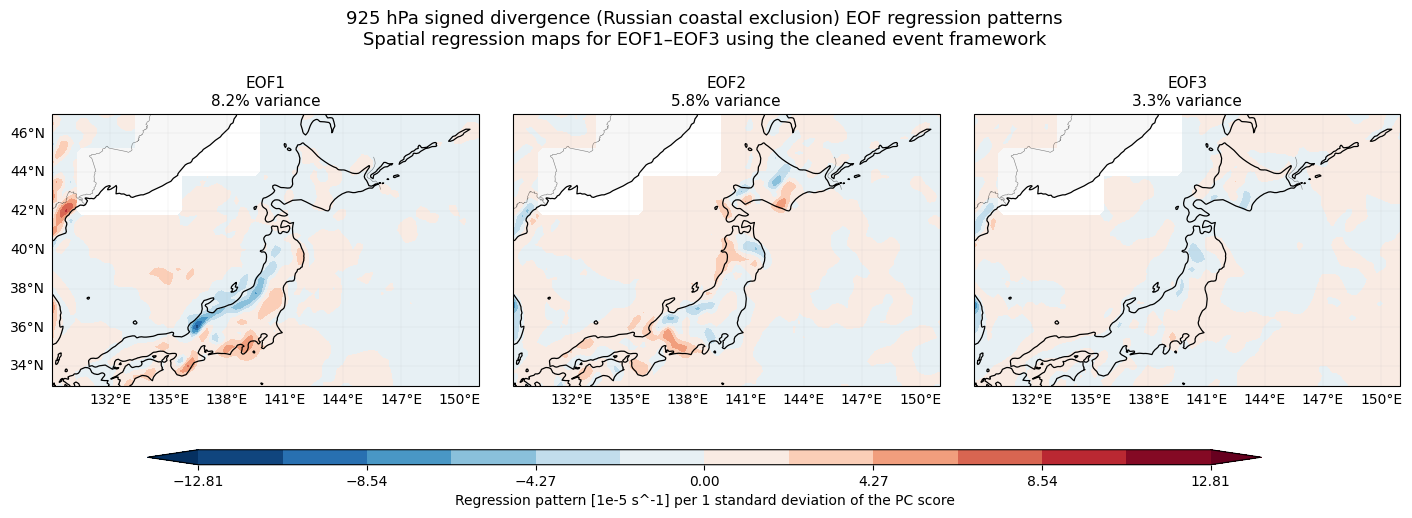

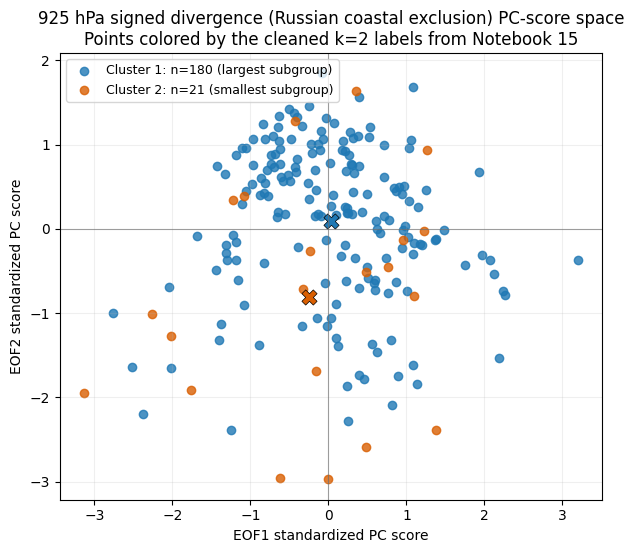

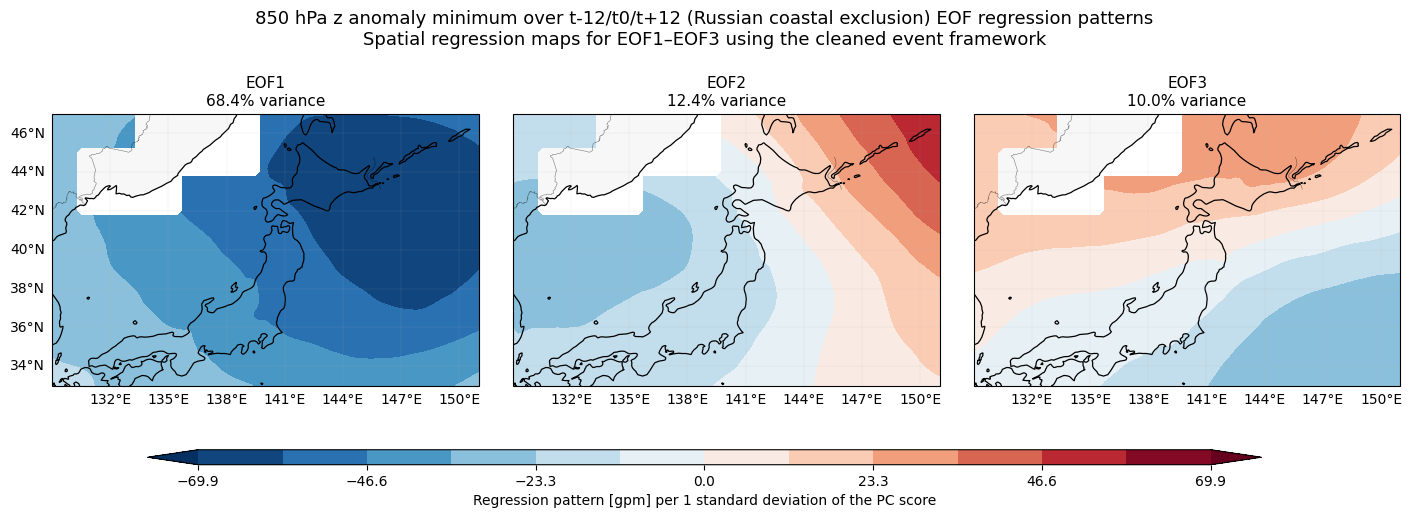

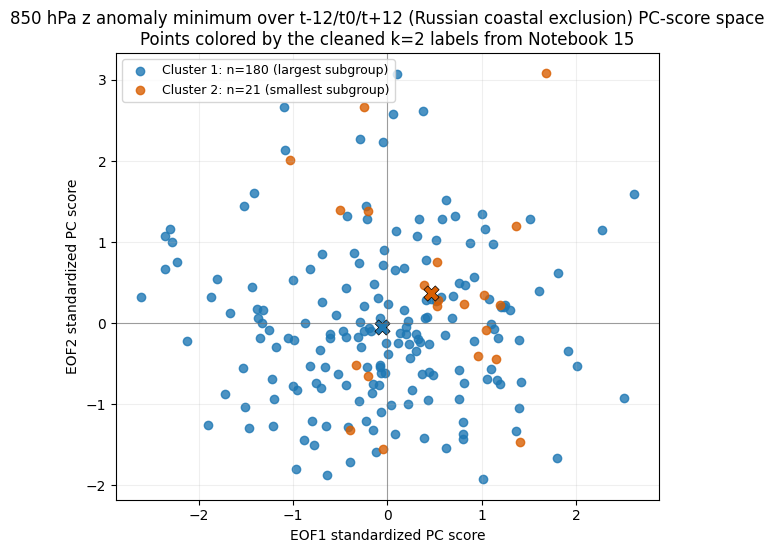

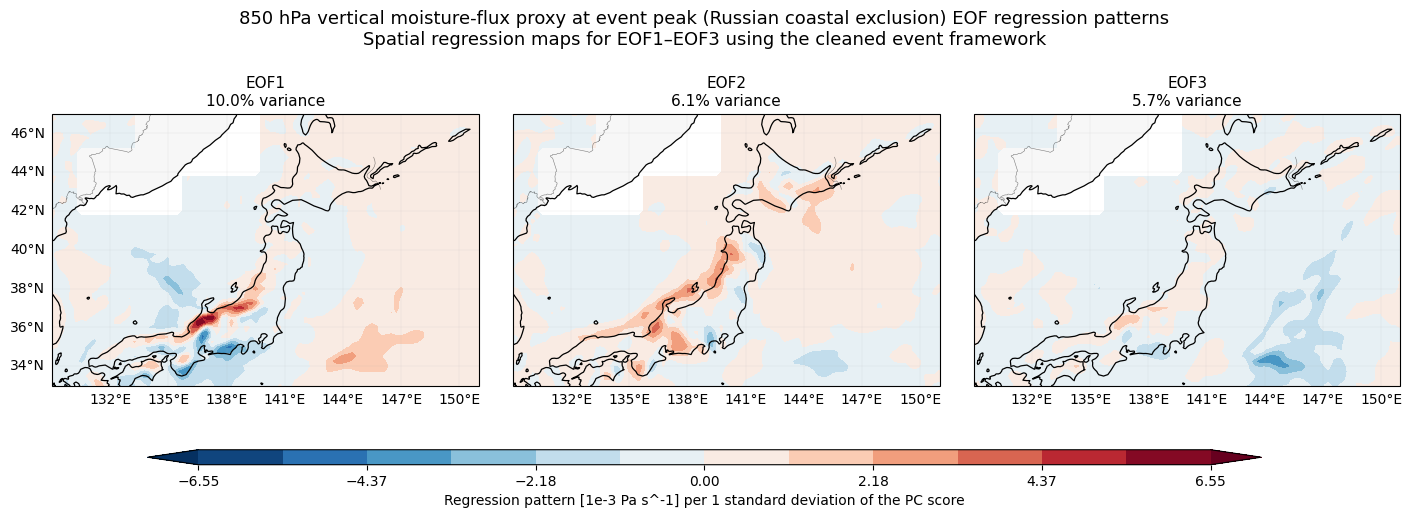

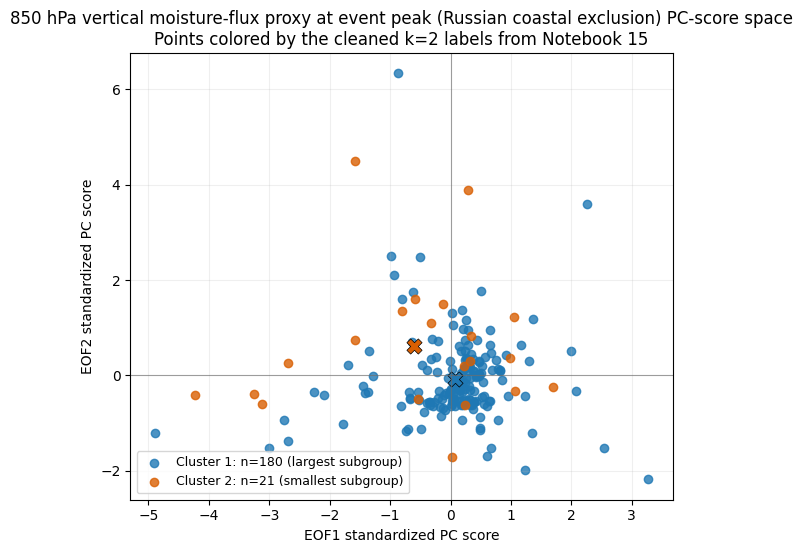

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


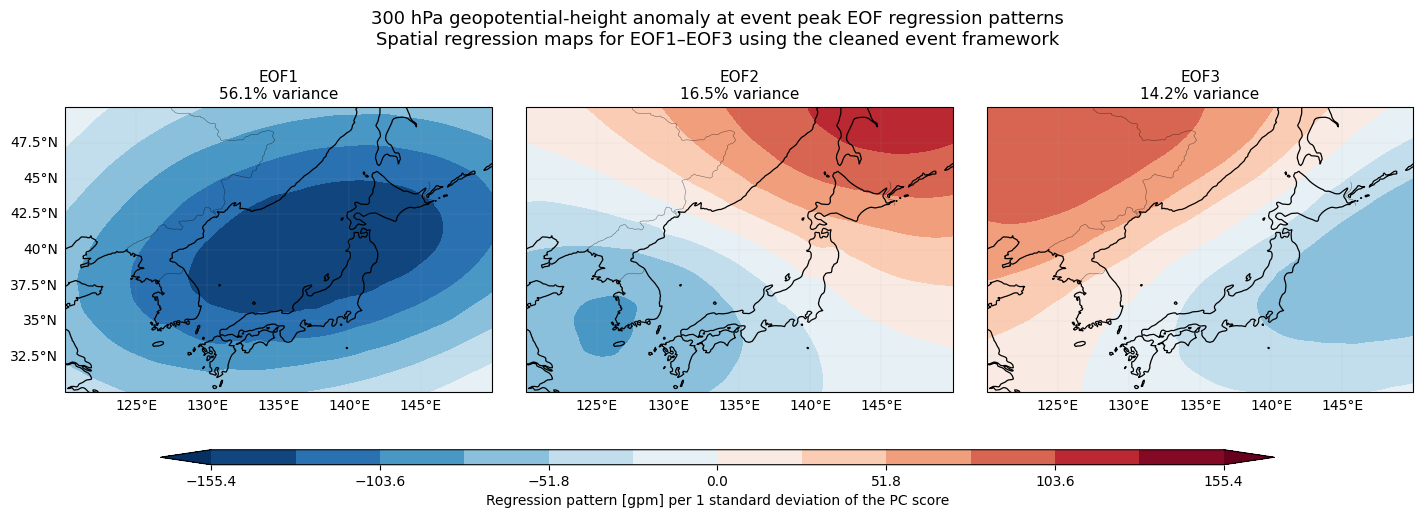

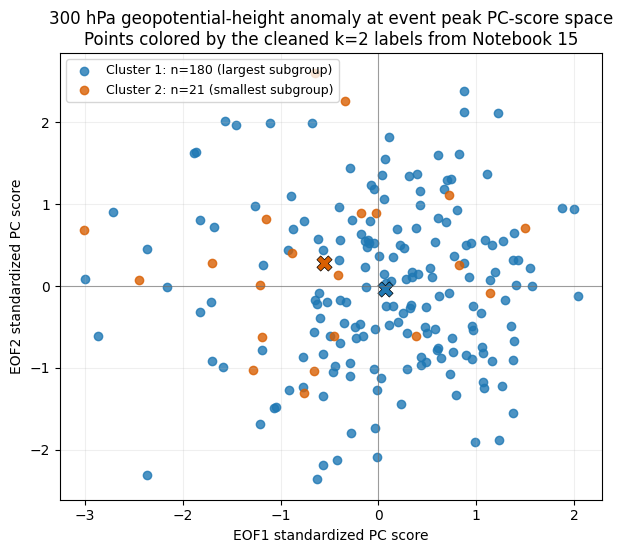

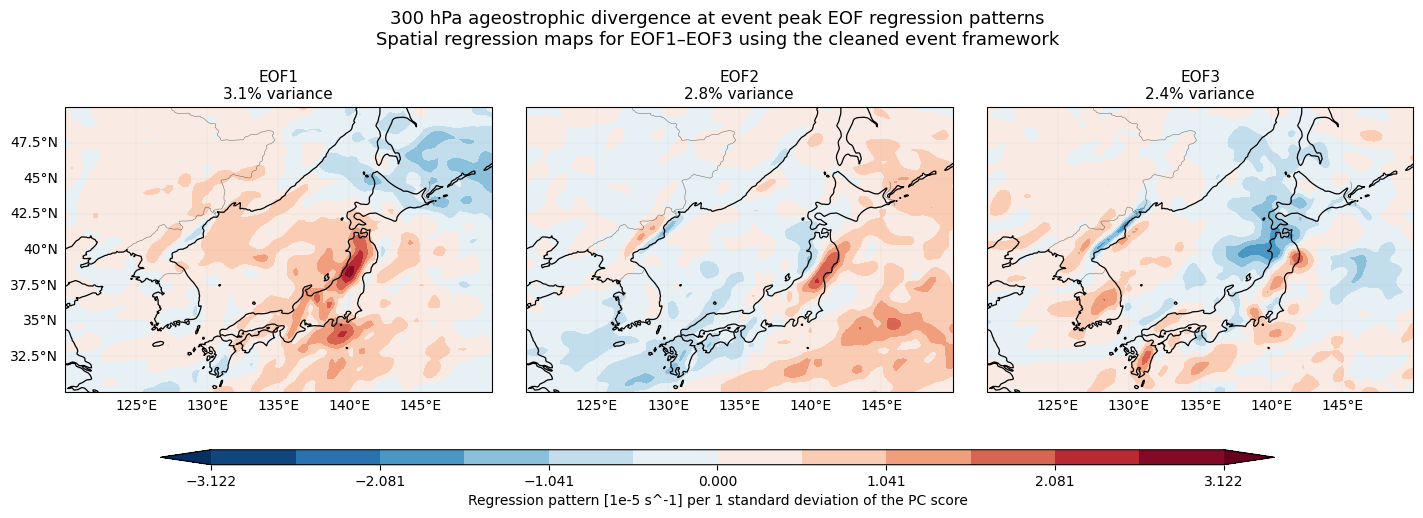

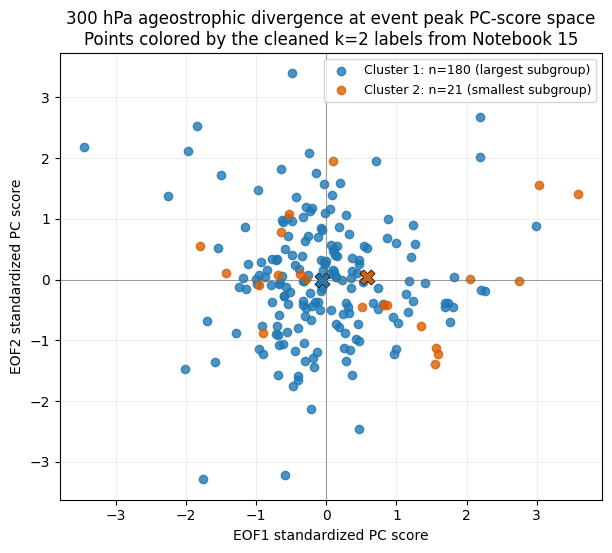

Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_eof_plot_inventory.csv
Saved EOF plot inventory


,plot_kind,field,local_path,drive_path
0,eof_pattern_maps,divergence_925_peak,outputs/verification/objective_subtype_eof_plo...,/content/drive/MyDrive/JPCZcatalog_outputs/eof...
1,pc_score_scatter,divergence_925_peak,outputs/verification/objective_subtype_eof_plo...,/content/drive/MyDrive/JPCZcatalog_outputs/eof...
2,eof_pattern_maps,z850_anomaly_min_tminus12_to_tplus12,outputs/verification/objective_subtype_eof_plo...,/content/drive/MyDrive/JPCZcatalog_outputs/eof...
3,pc_score_scatter,z850_anomaly_min_tminus12_to_tplus12,outputs/verification/objective_subtype_eof_plo...,/content/drive/MyDrive/JPCZcatalog_outputs/eof...
4,eof_pattern_maps,vertical_moisture_flux_proxy_850_peak,outputs/verification/objective_subtype_eof_plo...,/content/drive/MyDrive/JPCZcatalog_outputs/eof...
5,pc_score_scatter,vertical_moisture_flux_proxy_850_peak,outputs/verification/objective_subtype_eof_plo...,/content/drive/MyDrive/JPCZcatalog_outputs/eof...
6,eof_pattern_maps,z300_anomaly_peak,outputs/verification/objective_subtype_eof_plo...,/content/drive/MyDrive/JPCZcatalog_outputs/eof...
7,pc_score_scatter,z300_anomaly_peak,outputs/verification/objective_subtype_eof_plo...,/content/drive/MyDrive/JPCZcatalog_outputs/eof...
8,eof_pattern_maps,ageostrophic_divergence_300_peak,outputs/verification/objective_subtype_eof_plo...,/content/drive/MyDrive/JPCZcatalog_outputs/eof...
9,pc_score_scatter,ageostrophic_divergence_300_peak,outputs/verification/objective_subtype_eof_plo...,/content/drive/MyDrive/JPCZcatalog_outputs/eof...


In [10]:

required_globals = [
    "eof_pattern_datasets",
    "variance_long_df",
    "score_long_df",
    "cluster_label_lookup",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "Run the Notebook 17 EOF analysis cell before the plotting cell. "
        f"Missing globals: {missing_globals}"
    )

import cartopy.crs as ccrs
import cartopy.feature as cfeature

plot_inventory_rows = []
for spec in EOF_FIELD_SPECS:
    field_name = spec["field"]
    field_label = spec["field_label"]
    plot_domain = spec["plot_domain"]
    pattern_ds = eof_pattern_datasets[field_name]
    pattern_da = pattern_ds["eof_regression_pattern"]
    levels = build_eof_levels(pattern_da)

    fig, axes = plt.subplots(1, min(N_EOF_MODES, pattern_da.sizes["mode"]), figsize=(5.8 * min(N_EOF_MODES, pattern_da.sizes["mode"]), 5.0), subplot_kw={"projection": ccrs.PlateCarree()})
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])

    mappable = None
    for ax, mode_name in zip(axes, pattern_da["mode"].values.tolist()):
        pattern = pattern_da.sel(mode=mode_name)
        mappable = ax.contourf(
            pattern.longitude,
            pattern.latitude,
            pattern,
            levels=levels,
            cmap=spec["plot_cmap"],
            extend="both",
            transform=ccrs.PlateCarree(),
        )
        ax.set_extent(
            [plot_domain.lon_min, plot_domain.lon_max, plot_domain.lat_min, plot_domain.lat_max],
            crs=ccrs.PlateCarree(),
        )
        ax.coastlines(resolution="50m", linewidth=0.9)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.5)
        ax.add_feature(cfeature.LAND, facecolor="#f2f2f2", alpha=0.6)
        gl = ax.gridlines(draw_labels=True, linewidth=0.25, alpha=0.35)
        gl.top_labels = False
        gl.right_labels = False
        if ax is not axes[0]:
            gl.left_labels = False
        explained = float(variance_long_df.loc[(variance_long_df["field"] == field_name) & (variance_long_df["mode"] == mode_name), "explained_variance_percent"].iloc[0])
        ax.set_title(f"{mode_name}\n{explained:.1f}% variance", fontsize=11)

    fig.suptitle(
        f"{field_label} EOF regression patterns\nSpatial regression maps for EOF1–EOF3 using the cleaned event framework",
        y=0.98,
        fontsize=13,
    )
    fig.subplots_adjust(top=0.84, bottom=0.16, wspace=0.08)
    cbar_ax = fig.add_axes([0.18, 0.07, 0.64, 0.03])
    cbar = fig.colorbar(mappable, cax=cbar_ax, orientation="horizontal")
    cbar.set_label(f"Regression pattern [{spec['units']}] per 1 standard deviation of the PC score")
    pattern_plot_path = PLOT_DIR / f"eof_patterns_{field_name}.png"
    if SAVE_PLOTS:
        fig.savefig(pattern_plot_path, dpi=180, bbox_inches="tight")
        drive_path = maybe_copy_to_drive(pattern_plot_path, verbose=False)
    else:
        drive_path = None
    plot_inventory_rows.append(
        {
            "plot_kind": "eof_pattern_maps",
            "field": field_name,
            "local_path": str(pattern_plot_path),
            "drive_path": str(drive_path) if drive_path is not None else "",
        }
    )
    plt.show(fig)

    score_subset = score_long_df.loc[score_long_df["field"] == field_name].copy()
    fig, ax = plt.subplots(figsize=(7.0, 5.8))
    for cluster_id in sorted(score_subset[PRIMARY_CLUSTER_COLUMN].dropna().astype(int).unique()):
        subset = score_subset.loc[score_subset[PRIMARY_CLUSTER_COLUMN] == cluster_id]
        ax.scatter(
            subset["EOF1_standardized"],
            subset["EOF2_standardized"],
            s=36,
            alpha=0.8,
            color=CLUSTER_COLOR_MAP.get(int(cluster_id), "#333333"),
            label=cluster_label_lookup[int(cluster_id)],
        )
        ax.scatter(
            subset["EOF1_standardized"].mean(),
            subset["EOF2_standardized"].mean(),
            s=120,
            marker="X",
            color=CLUSTER_COLOR_MAP.get(int(cluster_id), "#333333"),
            edgecolor="black",
            linewidth=0.5,
        )
    ax.axhline(0.0, color="#666666", linewidth=0.8, alpha=0.6)
    ax.axvline(0.0, color="#666666", linewidth=0.8, alpha=0.6)
    ax.set_xlabel("EOF1 standardized PC score")
    ax.set_ylabel("EOF2 standardized PC score")
    ax.set_title(
        f"{field_label} PC-score space\nPoints colored by the cleaned k=2 labels from Notebook 15",
        fontsize=12,
    )
    ax.legend(loc="best", fontsize=9)
    ax.grid(alpha=0.2)
    scatter_plot_path = PLOT_DIR / f"eof_scores_scatter_{field_name}.png"
    if SAVE_PLOTS:
        fig.savefig(scatter_plot_path, dpi=180, bbox_inches="tight")
        drive_path = maybe_copy_to_drive(scatter_plot_path, verbose=False)
    else:
        drive_path = None
    plot_inventory_rows.append(
        {
            "plot_kind": "pc_score_scatter",
            "field": field_name,
            "local_path": str(scatter_plot_path),
            "drive_path": str(drive_path) if drive_path is not None else "",
        }
    )
    plt.show(fig)

plot_inventory_df = pd.DataFrame(plot_inventory_rows)
plot_inventory_df.to_csv(PLOT_INVENTORY_PATH, index=False)
maybe_copy_to_drive(PLOT_INVENTORY_PATH)

print("Saved EOF plot inventory")
display(plot_inventory_df)


In [11]:

required_globals = [
    "variance_long_df",
    "cluster_score_summary_long_df",
    "pattern_summary_long_df",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "Run the Notebook 17 EOF analysis cell before the EOF summary cell. "
        f"Missing globals: {missing_globals}"
    )

dominant_mode_df = (
    variance_long_df.sort_values(["field", "explained_variance_ratio"], ascending=[True, False])
    .groupby(["field", "field_label"], as_index=False)
    .first()[["field", "field_label", "mode", "explained_variance_percent", "n_valid_space_points"]]
    .rename(columns={
        "mode": "dominant_mode",
        "explained_variance_percent": "dominant_mode_explained_variance_percent",
    })
)

dominant_mode_df["dominant_mode_explained_variance_percent"] = dominant_mode_df["dominant_mode_explained_variance_percent"].round(2)
cluster_score_summary_long_df["mean_pc_score"] = cluster_score_summary_long_df["mean_pc_score"].round(3)
cluster_score_summary_long_df["median_pc_score"] = cluster_score_summary_long_df["median_pc_score"].round(3)
cluster_score_summary_long_df["std_pc_score"] = cluster_score_summary_long_df["std_pc_score"].round(3)
cluster_score_summary_long_df["mean_standardized_pc_score"] = cluster_score_summary_long_df["mean_standardized_pc_score"].round(3)
pattern_summary_long_df["min_pattern_value"] = pattern_summary_long_df["min_pattern_value"].round(3)
pattern_summary_long_df["max_pattern_value"] = pattern_summary_long_df["max_pattern_value"].round(3)
pattern_summary_long_df["max_abs_pattern_value"] = pattern_summary_long_df["max_abs_pattern_value"].round(3)

print("Dominant EOF mode by field")
display(dominant_mode_df)
print("\nCluster-wise EOF PC-score summary")
display(cluster_score_summary_long_df)
print("\nEOF pattern-amplitude summary")
display(pattern_summary_long_df)
print("\nNotebook 17 now does the following:")
print("- builds gridded event stacks for the cleaned low-level and upper-level fields")
print("- computes true spatial EOFs rather than the 4-feature clustering PCA")
print("- plots the first three EOF regression patterns for each selected field")
print("- saves PC-score tables so we can compare the EOF space with the cleaned k=2 clusters")
print("- sets up the next step of asking whether the cleaned clusters align with coherent spatial variance modes")


Dominant EOF mode by field


,field,field_label,dominant_mode,dominant_mode_explained_variance_percent,n_valid_space_points
0,ageostrophic_divergence_300_peak,300 hPa ageostrophic divergence at event peak,EOF1,3.08,9801
1,divergence_925_peak,925 hPa signed divergence (Russian coastal exc...,EOF1,8.17,4520
2,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,EOF1,9.98,4520
3,z300_anomaly_peak,300 hPa geopotential-height anomaly at event peak,EOF1,56.07,9801
4,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,EOF1,68.40,4520



Cluster-wise EOF PC-score summary


,field,field_label,cleaned_cluster_ward_2,cluster_label,mode,mean_pc_score,median_pc_score,std_pc_score,mean_standardized_pc_score,n_events
0,divergence_925_peak,925 hPa signed divergence (Russian coastal exc...,1,Cluster 1: n=180 (largest subgroup),EOF1,2.067,6.154,68.533,0.029,180
1,divergence_925_peak,925 hPa signed divergence (Russian coastal exc...,1,Cluster 1: n=180 (largest subgroup),EOF2,5.678,13.496,54.649,0.095,180
2,divergence_925_peak,925 hPa signed divergence (Russian coastal exc...,1,Cluster 1: n=180 (largest subgroup),EOF3,-2.089,-1.428,42.396,-0.046,180
3,divergence_925_peak,925 hPa signed divergence (Russian coastal exc...,2,Cluster 2: n=21 (smallest subgroup),EOF1,-17.720,-11.398,90.626,-0.249,21
4,divergence_925_peak,925 hPa signed divergence (Russian coastal exc...,2,Cluster 2: n=21 (smallest subgroup),EOF2,-48.671,-42.597,80.822,-0.811,21
5,divergence_925_peak,925 hPa signed divergence (Russian coastal exc...,2,Cluster 2: n=21 (smallest subgroup),EOF3,17.903,14.237,61.945,0.397,21
6,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,1,Cluster 1: n=180 (largest subgroup),EOF1,-157.096,-117.512,2968.238,-0.054,180
7,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,1,Cluster 1: n=180 (largest subgroup),EOF2,-54.004,-163.694,1199.911,-0.043,180
8,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,1,Cluster 1: n=180 (largest subgroup),EOF3,76.042,128.883,1081.793,0.068,180
9,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,2,Cluster 2: n=21 (smallest subgroup),EOF1,1346.533,1537.418,2216.760,0.459,21



EOF pattern-amplitude summary


,field,field_label,mode,min_pattern_value,max_pattern_value,max_abs_pattern_value,n_valid_space_points
0,divergence_925_peak,925 hPa signed divergence (Russian coastal exc...,EOF1,-12.810,8.838,12.810,4520
1,divergence_925_peak,925 hPa signed divergence (Russian coastal exc...,EOF2,-9.609,6.119,9.609,4520
2,divergence_925_peak,925 hPa signed divergence (Russian coastal exc...,EOF3,-10.451,2.871,10.451,4520
3,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,EOF1,-69.882,-20.147,69.882,4520
4,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,EOF2,-30.792,52.264,52.264,4520
5,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,EOF3,-34.913,33.504,34.913,4520
6,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,EOF1,-5.195,6.553,6.553,4520
7,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,EOF2,-3.344,3.547,3.547,4520
8,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,EOF3,-4.001,2.088,4.001,4520
9,z300_anomaly_peak,300 hPa geopotential-height anomaly at event peak,EOF1,-155.386,-8.418,155.386,9801



Notebook 17 now does the following:
- builds gridded event stacks for the cleaned low-level and upper-level fields
- computes true spatial EOFs rather than the 4-feature clustering PCA
- plots the first three EOF regression patterns for each selected field
- saves PC-score tables so we can compare the EOF space with the cleaned k=2 clusters
- sets up the next step of asking whether the cleaned clusters align with coherent spatial variance modes


### How to read the result

- The maps here are **EOF regression patterns**, meaning they show how the field anomaly changes for a one-standard-deviation increase in each PC score.
- EOF1, EOF2, and EOF3 are orthogonal modes in the weighted event-by-grid space for each field.
- The PC-score scatter plots let us see whether the cleaned `k = 2` event groups line up with any of those dominant variance modes.
- If the leading EOFs are spatially coherent and the cleaned clusters occupy distinct parts of PC-score space, that supports the idea that the cleaned subtype framework is physically meaningful rather than just numerically separable.
